## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, 
    roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
customer = pd.read_csv('../data/customer.csv')
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

print(f"Tổng số khách hàng: {len(customer)}")
print(f"Tổng số giao dịch: {len(df_success)}")

Tổng số khách hàng: 4314
Tổng số giao dịch: 407695


## 3. TẠO FEATURE (6 THÁNG ĐẦU)

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)
six_months_ago = now - pd.Timedelta(days=180)

first_6_months = df_success[df_success['InvoiceDate'] < six_months_ago]

In [4]:
# Feature engineering
rfm_features = first_6_months.groupby('Customer ID').agg({
    'InvoiceDate': [
        lambda x: (now - x.max()).days,  # Recency
        lambda x: (x.max() - x.min()).days,  # Customer lifespan
        lambda x: x.nunique()  # Number of unique dates
    ],
    'Invoice': 'nunique',  # Frequency
    'Amount': ['sum', 'mean', 'std'],  # Monetary
    'Quantity': ['sum', 'mean', 'std'],  # Purchase behavior
    'Price': ['mean', 'std'],  # Product price behavior
    'StockCode': 'nunique'  # Product diversity
})

In [5]:
# Rename columns
rfm_features.columns = [
    'Recency', 'Lifespan', 'Unique_Dates',
    'Frequency', 
    'Monetary_Sum', 'Monetary_Mean', 'Monetary_Std',
    'Quantity_Sum', 'Quantity_Mean', 'Quantity_Std',
    'Price_Mean', 'Price_Std',
    'Unique_Products'
]

In [6]:
# Feature: Average days between purchases
first_6_months_sorted = first_6_months.sort_values(['Customer ID', 'InvoiceDate'])
first_6_months_sorted['Prev_Date'] = first_6_months_sorted.groupby('Customer ID')['InvoiceDate'].shift(1)
first_6_months_sorted['Days_Between'] = (first_6_months_sorted['InvoiceDate'] - first_6_months_sorted['Prev_Date']).dt.days

avg_days_between = first_6_months_sorted.groupby('Customer ID')['Days_Between'].agg(['mean', 'std', 'min', 'max'])
avg_days_between.columns = ['Avg_Days_Between', 'Std_Days_Between', 'Min_Days_Between', 'Max_Days_Between']

In [7]:
# Merge all features
X = rfm_features.join(avg_days_between, how='left')

In [8]:
# Fill missing values (khách hàng chỉ mua 1 lần)
X['Avg_Days_Between'] = X['Avg_Days_Between'].fillna(365)
X['Std_Days_Between'] = X['Std_Days_Between'].fillna(0)
X['Min_Days_Between'] = X['Min_Days_Between'].fillna(365)
X['Max_Days_Between'] = X['Max_Days_Between'].fillna(365)
X['Monetary_Std'] = X['Monetary_Std'].fillna(0)
X['Quantity_Std'] = X['Quantity_Std'].fillna(0)
X['Price_Std'] = X['Price_Std'].fillna(0)

print(f"\nSố features đã tạo: {X.shape[1]}")



Số features đã tạo: 17


## 4. TẠO TARGET (CHURN)

In [9]:
last_6_months = df_success[df_success['InvoiceDate'] >= six_months_ago]
active_customers = set(last_6_months['Customer ID'].unique())

In [10]:
# Churn = 1 nếu không mua trong 6 tháng cuối, 0 nếu có mua
y = pd.Series(
    [1 if idx not in active_customers else 0 for idx in X.index],
    index=X.index,
    name='Churn'
)

churn_rate = y.mean()
print(f"\nTỷ lệ churn: {churn_rate*100:.1f}%")
print(f"  - Số khách hàng churn (không mua lại): {(y == 1).sum()}")
print(f"  - Số khách hàng active (có mua lại): {(y == 0).sum()}")


Tỷ lệ churn: 29.4%
  - Số khách hàng churn (không mua lại): 833
  - Số khách hàng active (có mua lại): 1997


## 5. EDA - PHÂN TÍCH KHÁM PHÁ

In [11]:
# So sánh đặc điểm giữa Churn và Active
churn_stats = X.join(y).groupby('Churn').mean().T
churn_stats.columns = ['Active (0)', 'Churn (1)']
churn_stats['Diff'] = churn_stats['Churn (1)'] - churn_stats['Active (0)']
churn_stats['Diff_%'] = (churn_stats['Diff'] / churn_stats['Active (0)'] * 100)

print("\nSo sánh đặc điểm Churn vs Active:")
print(churn_stats.sort_values('Diff_%', ascending=False).head(10))


So sánh đặc điểm Churn vs Active:
                  Active (0)   Churn (1)       Diff      Diff_%
Price_Mean          3.636073   28.884892  25.248819  694.398116
Min_Days_Between    5.538307   20.284514  14.746206  266.258355
Avg_Days_Between    7.199060   21.293409  14.094350  195.780416
Monetary_Mean      31.521159   56.272474  24.751314   78.522856
Recency           234.260391  264.427371  30.166980   12.877542
Quantity_Mean      22.018707   23.968638   1.949931    8.855791
Quantity_Std       17.808520   17.537861  -0.270659   -1.519826
Price_Std           4.083602    3.866927  -0.216675   -5.305985
Max_Days_Between   48.200300   38.996399  -9.203902  -19.095113
Monetary_Std       21.604868   17.252799  -4.352069  -20.143930


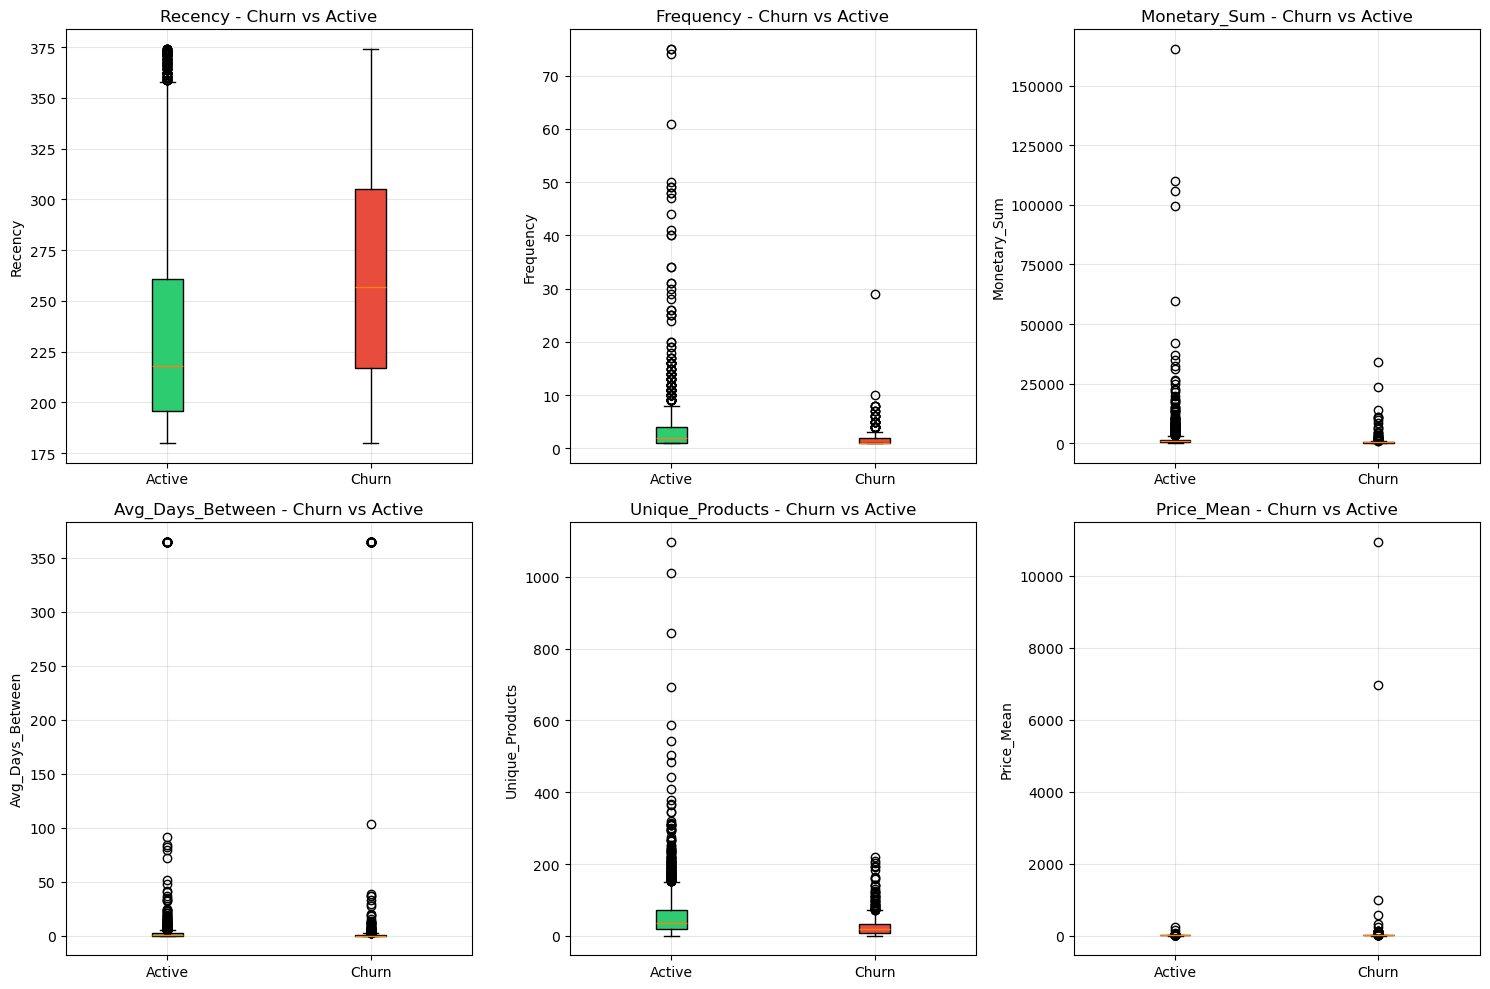

In [12]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['Recency', 'Frequency', 'Monetary_Sum', 'Avg_Days_Between', 'Unique_Products', 'Price_Mean']

for i, feature in enumerate(features_to_plot):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    data_to_plot = [X[y == 0][feature], X[y == 1][feature]]
    bp = ax.boxplot(data_to_plot, labels=['Active', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ECC71')
    bp['boxes'][1].set_facecolor('#E74C3C')
    ax.set_title(f'{feature} - Churn vs Active')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

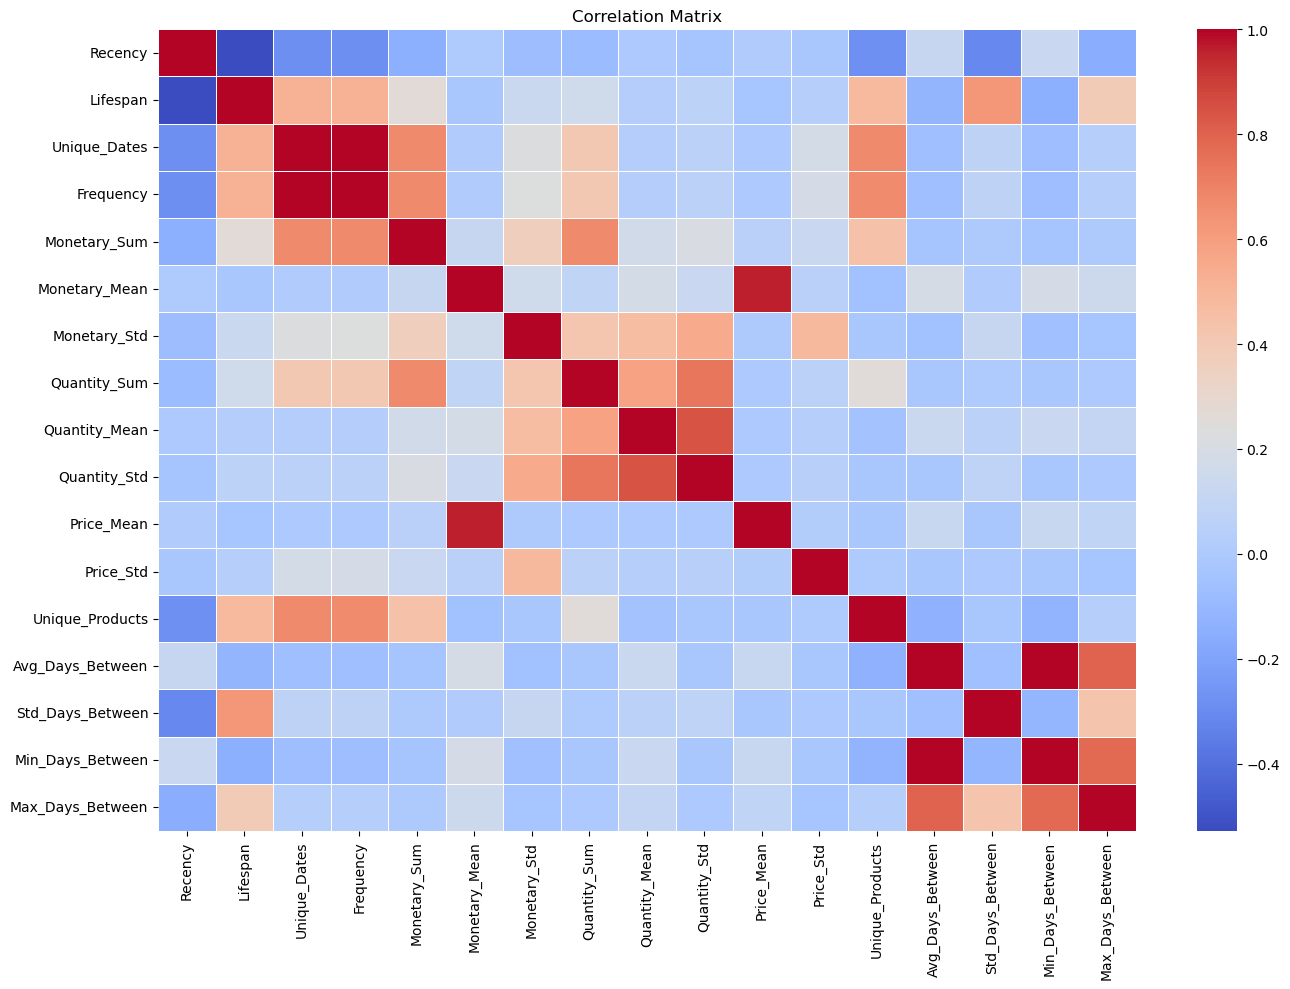

In [13]:
# Correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 6. CHUẨN BỊ DỮ LIỆU CHO MODEL

In [14]:
print("XỬ LÝ IMBALANCED DATA")
print(f"Churn: {y.sum()} ({churn_rate*100:.1f}%)")
print(f"Active: {(1-y).sum()} {(1-churn_rate)*100:.1f}%)")

XỬ LÝ IMBALANCED DATA
Churn: 833 (29.4%)
Active: 1997 70.6%)


In [15]:
# Class weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights: {class_weight_dict}")


Class weights: {0: np.float64(0.7085628442663996), 1: np.float64(1.6986794717887155)}


In [16]:
# Chia train/test với stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {len(X_train)} samples")
print(f"  - Churn: {y_train.sum()} | Active: {len(y_train)-y_train.sum()}")
print(f"Test set: {len(X_test)} samples")
print(f"  - Churn: {y_test.sum()} | Active: {len(y_test)-y_test.sum()}")


Train set: 2264 samples
  - Churn: 666 | Active: 1598
Test set: 566 samples
  - Churn: 167 | Active: 399


In [17]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. TRAIN CÁC MODEL

In [18]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )
}


## 8. ĐÁNH GIÁ MODEL


In [19]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'CV-AUC Mean': cv_scores.mean(),
        'CV-AUC Std': cv_scores.std()
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"  Confusion Matrix: [{cm[0][0]} {cm[0][1]} / {cm[1][0]} {cm[1][1]}]")

Training Logistic Regression...
  Accuracy: 0.6219
  Precision: 0.4254
  Recall: 0.8024
  F1-Score: 0.5560
  ROC-AUC: 0.7351
  CV AUC: 0.7395 (+/- 0.0298)
  Confusion Matrix: [218 181 / 33 134]
Training Decision Tree...
  Accuracy: 0.6095
  Precision: 0.3875
  Recall: 0.5569
  F1-Score: 0.4570
  ROC-AUC: 0.6034
  CV AUC: 0.6245 (+/- 0.0149)
  Confusion Matrix: [252 147 / 74 93]
Training Random Forest...
  Accuracy: 0.6749
  Precision: 0.4444
  Recall: 0.4072
  F1-Score: 0.4250
  ROC-AUC: 0.7238
  CV AUC: 0.7359 (+/- 0.0191)
  Confusion Matrix: [314 85 / 99 68]
Training Gradient Boosting...
  Accuracy: 0.6996
  Precision: 0.4880
  Recall: 0.3653
  F1-Score: 0.4178
  ROC-AUC: 0.7366
  CV AUC: 0.7157 (+/- 0.0195)
  Confusion Matrix: [335 64 / 106 61]


## 9. SO SÁNH CÁC MODEL

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Logistic Regression    0.6219     0.4254  0.8024    0.5560   0.7351   
Decision Tree          0.6095     0.3875  0.5569    0.4570   0.6034   
Random Forest          0.6749     0.4444  0.4072    0.4250   0.7238   
Gradient Boosting      0.6996     0.4880  0.3653    0.4178   0.7366   

                     CV-AUC Mean  CV-AUC Std  
Logistic Regression       0.7395      0.0298  
Decision Tree             0.6245      0.0149  
Random Forest             0.7359      0.0191  
Gradient Boosting         0.7157      0.0195  


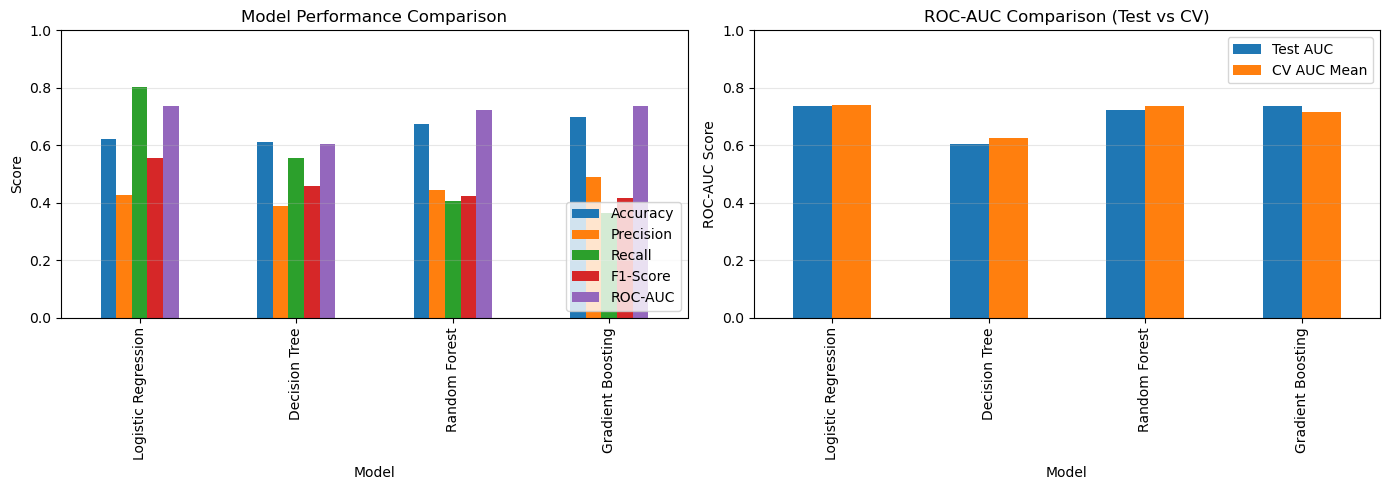

In [20]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df[metrics_to_plot].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

results_df[['ROC-AUC', 'CV-AUC Mean']].plot(kind='bar', ax=axes[1])
axes[1].set_title('ROC-AUC Comparison (Test vs CV)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].legend(['Test AUC', 'CV AUC Mean'])
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 10. CHỌN MODEL TỐT NHẤT

In [21]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]

print(f"MODEL TỐT NHẤT: {best_model_name}")
print(f"F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"Recall: {results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"Precision: {results_df.loc[best_model_name, 'Precision']:.4f}")

MODEL TỐT NHẤT: Logistic Regression
F1-Score: 0.5560
ROC-AUC: 0.7351
Recall: 0.8024
Precision: 0.4254


## 11. FEATURE IMPORTANCE

In [22]:
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*60)
    print("TOP 15 FEATURE QUAN TRỌNG NHẤT")
    print("="*60)
    print(feature_importance.head(15))
    
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    feature_importance.to_csv('../data/feature_importance_churn.csv', index=False)

## 12. ROC CURVE

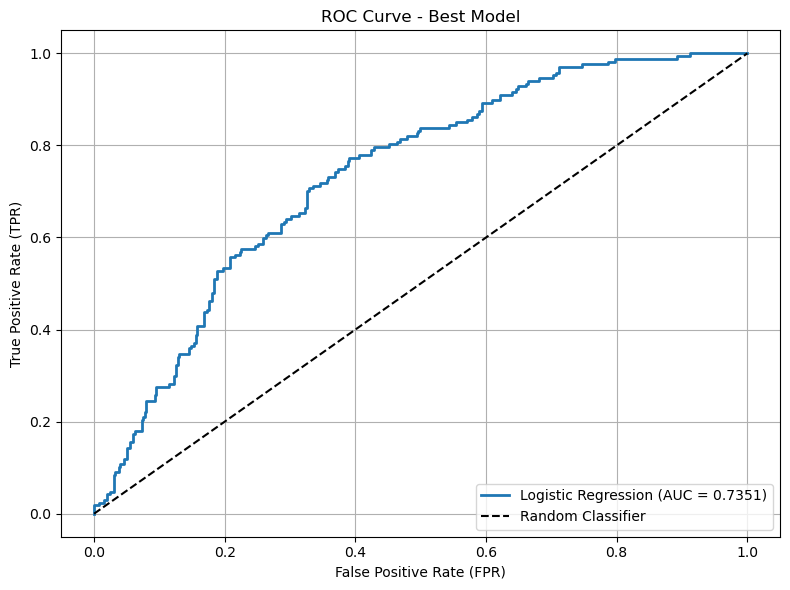

In [23]:
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_pred_proba_best):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. PRECISION-RECALL CURVE`

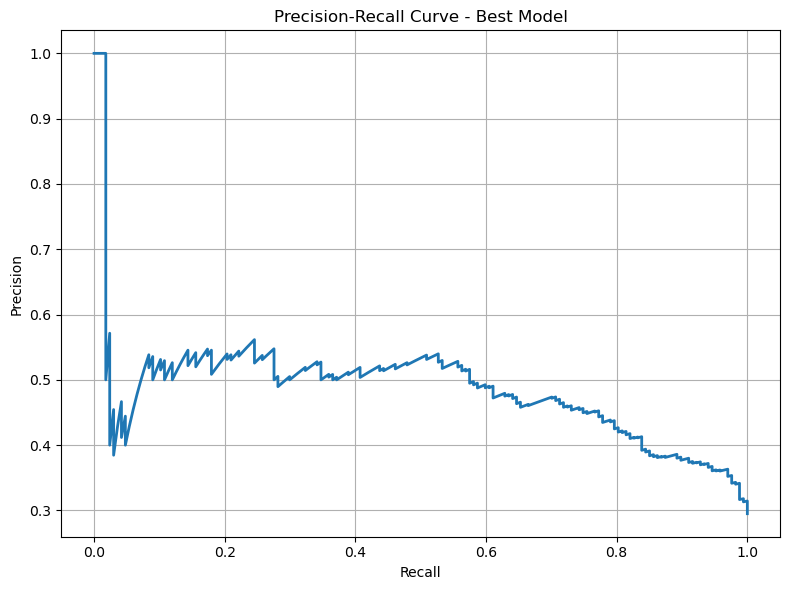

In [24]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best Model')
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
## 14. TÌM OPTIMAL THRESHOLD

In [26]:
optimal_threshold_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_threshold_idx]

print("OPTIMAL THRESHOLD")
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Tại threshold này:")
print(f"  - True Positive Rate: {tpr[optimal_threshold_idx]:.4f}")
print(f"  - False Positive Rate: {fpr[optimal_threshold_idx]:.4f}")



OPTIMAL THRESHOLD
Optimal threshold: 0.5626
Tại threshold này:
  - True Positive Rate: 0.7725
  - False Positive Rate: 0.3910


## 15. LƯU MODEL

In [27]:
import joblib

artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
    'optimal_threshold': optimal_threshold,
    'class_weight': class_weight_dict
}

joblib.dump(artifacts, '../models/churn_model.pkl')
print(f"\n Đã lưu model vào 'models/churn_model.pkl'")


 Đã lưu model vào 'models/churn_model.pkl'


## 16. DỰ ĐOÁN CHO KHÁCH HÀNG MỚI

In [28]:
print("VÍ DỤ DỰ ĐOÁN CHO KHÁCH HÀNG MỚI")

sample_customers = X.sample(5)
sample_pred_proba = best_model.predict_proba(scaler.transform(sample_customers))[:, 1]
sample_pred = (sample_pred_proba >= optimal_threshold).astype(int)

sample_results = sample_customers.copy()
sample_results['Churn_Probability'] = sample_pred_proba
sample_results['Predicted_Churn'] = sample_pred
sample_results['Actual_Churn'] = y.loc[sample_results.index]

print(sample_results[['Recency', 'Frequency', 'Monetary_Sum', 'Churn_Probability', 'Predicted_Churn', 'Actual_Churn']])

VÍ DỤ DỰ ĐOÁN CHO KHÁCH HÀNG MỚI
             Recency  Frequency  Monetary_Sum  Churn_Probability  \
Customer ID                                                        
14413.0          318          2        465.50           0.786205   
18272.0          184          3       1307.40           0.288737   
17550.0          214          4       1468.25           0.183334   
13267.0          214          7       2431.86           0.117484   
14977.0          361          1         31.93           0.731908   

             Predicted_Churn  Actual_Churn  
Customer ID                                 
14413.0                    1             0  
18272.0                    0             1  
17550.0                    0             0  
13267.0                    0             0  
14977.0                    1             1  


## 17. KẾT LUẬN

In [31]:
print(f"""
1. Model tốt nhất: {best_model_name}
   - F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}
   - ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}
   - Recall: {results_df.loc[best_model_name, 'Recall']:.4f}
   - Precision: {results_df.loc[best_model_name, 'Precision']:.4f}

2. Tỷ lệ churn thực tế: {churn_rate*100:.1f}%
   - Số khách hàng churn: {(y == 1).sum()}
   - Số khách hàng active: {(y == 0).sum()}

3. Feature quan trọng nhất:""")

if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    print(f"""
   - {feature_importance.iloc[0]['Feature']}: {feature_importance.iloc[0]['Importance']:.4f}
   - {feature_importance.iloc[1]['Feature']}: {feature_importance.iloc[1]['Importance']:.4f}
   - {feature_importance.iloc[2]['Feature']}: {feature_importance.iloc[2]['Importance']:.4f}
""")
else:
    print("   (Logistic Regression không có feature importance)")

print(f"""
4. Optimal Threshold: {optimal_threshold:.4f}
   - True Positive Rate: {tpr[optimal_threshold_idx]:.4f}
   - False Positive Rate: {fpr[optimal_threshold_idx]:.4f}

5. Khuyến nghị:
   - Khách hàng có Recency > 30 ngày và Frequency < 3 lần => nguy cơ churn cao
   - Cần can thiệp sớm với khách hàng có Monetary giảm dần
   - Chiến dịch retargeting nên nhắm vào khách hàng có Probability > {optimal_threshold:.2f}
   - Tập trung giữ chân nhóm khách hàng có nguy cơ churn cao nhất
""")



1. Model tốt nhất: Logistic Regression
   - F1-Score: 0.5560
   - ROC-AUC: 0.7351
   - Recall: 0.8024
   - Precision: 0.4254

2. Tỷ lệ churn thực tế: 29.4%
   - Số khách hàng churn: 833
   - Số khách hàng active: 1997

3. Feature quan trọng nhất:
   (Logistic Regression không có feature importance)

4. Optimal Threshold: 0.5626
   - True Positive Rate: 0.7725
   - False Positive Rate: 0.3910

5. Khuyến nghị:
   - Khách hàng có Recency > 30 ngày và Frequency < 3 lần => nguy cơ churn cao
   - Cần can thiệp sớm với khách hàng có Monetary giảm dần
   - Chiến dịch retargeting nên nhắm vào khách hàng có Probability > 0.56
   - Tập trung giữ chân nhóm khách hàng có nguy cơ churn cao nhất

